<a href="https://colab.research.google.com/github/ishikamokati30/Sentiments-Analysis-using-NLP/blob/main/sentiment_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import numpy as np
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt

In [45]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [46]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

In [47]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [48]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


In [49]:
df = pd.read_csv("IMDB Dataset.csv")

In [50]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [51]:
df.shape

(50000, 2)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [53]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [54]:
df.isnull().sum()

,0
review,0
sentiment,0


In [55]:
df.duplicated().sum()

np.int64(418)

In [56]:
df = df.drop_duplicates()

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df.shape

(49582, 2)

In [59]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

In [60]:
df["clean_review"] = df["review"].apply(clean_text)

In [61]:
df["sentiment"] = df["sentiment"].map({
    "positive":1,
    "negative":0
})

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"],
    df["sentiment"],
    test_size=0.2
)

In [63]:
vectorizer = TfidfVectorizer(
max_features=5000,
ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [64]:
nb = MultinomialNB()
nb.fit(X_train_vec,y_train)

MultinomialNB()

In [65]:
lr = LogisticRegression()
lr.fit(X_train_vec,y_train)

LogisticRegression()

In [66]:
svm = LinearSVC()
svm.fit(X_train_vec,y_train)

LinearSVC()

In [70]:
pred = svm.predict(X_test_vec)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      5006
           1       0.88      0.88      0.88      4911

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



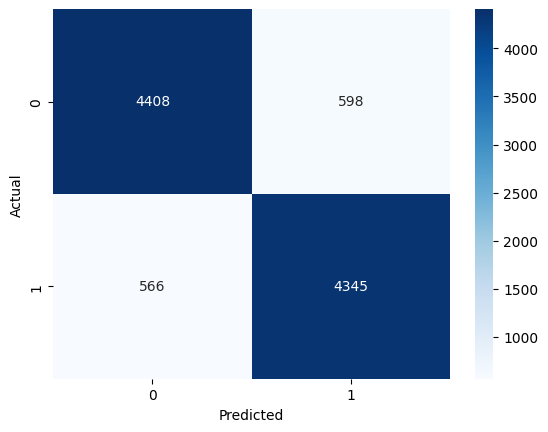

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

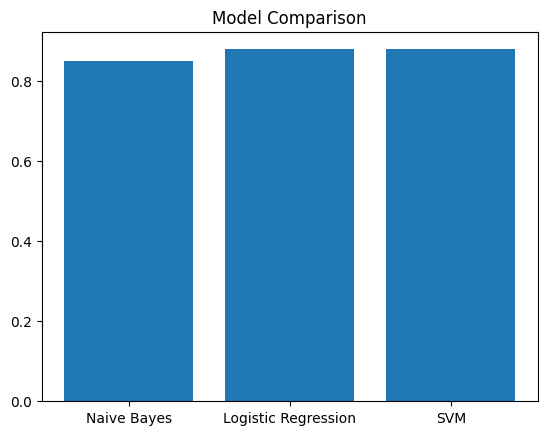

In [72]:
import matplotlib.pyplot as plt

models = ["Naive Bayes","Logistic Regression","SVM"]
accuracy = [0.85,0.88,0.88]

plt.bar(models,accuracy)

plt.title("Model Comparison")

plt.show()

In [73]:
import joblib

joblib.dump(svm,"sentiment_model.pkl")
joblib.dump(vectorizer,"vectorizer.pkl")

['vectorizer.pkl']

In [74]:
files.download("sentiment_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>